In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import warnings
plt.rcParams['font.family'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

In [4]:
from WeekendGrid import WeekendGridV1
wg1 = WeekendGridV1()

Getting Results: 100%|██████████| 580/580 [00:38<00:00, 15.18it/s]


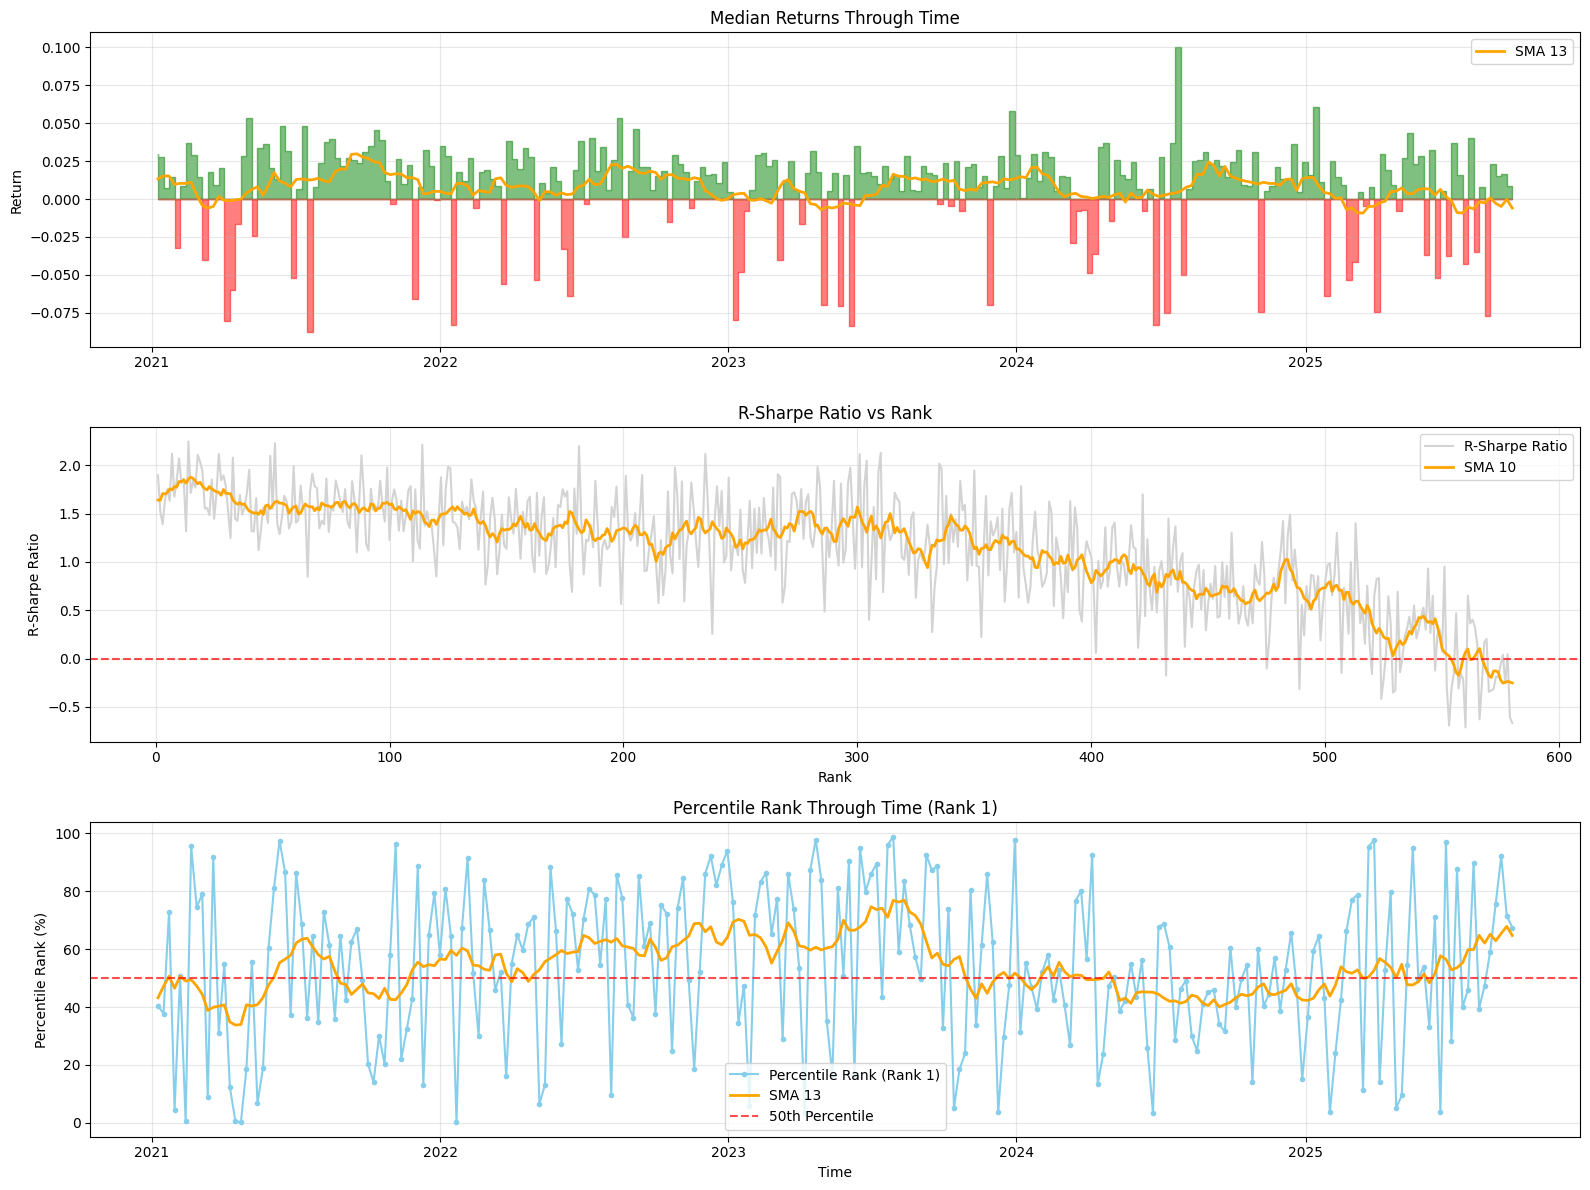

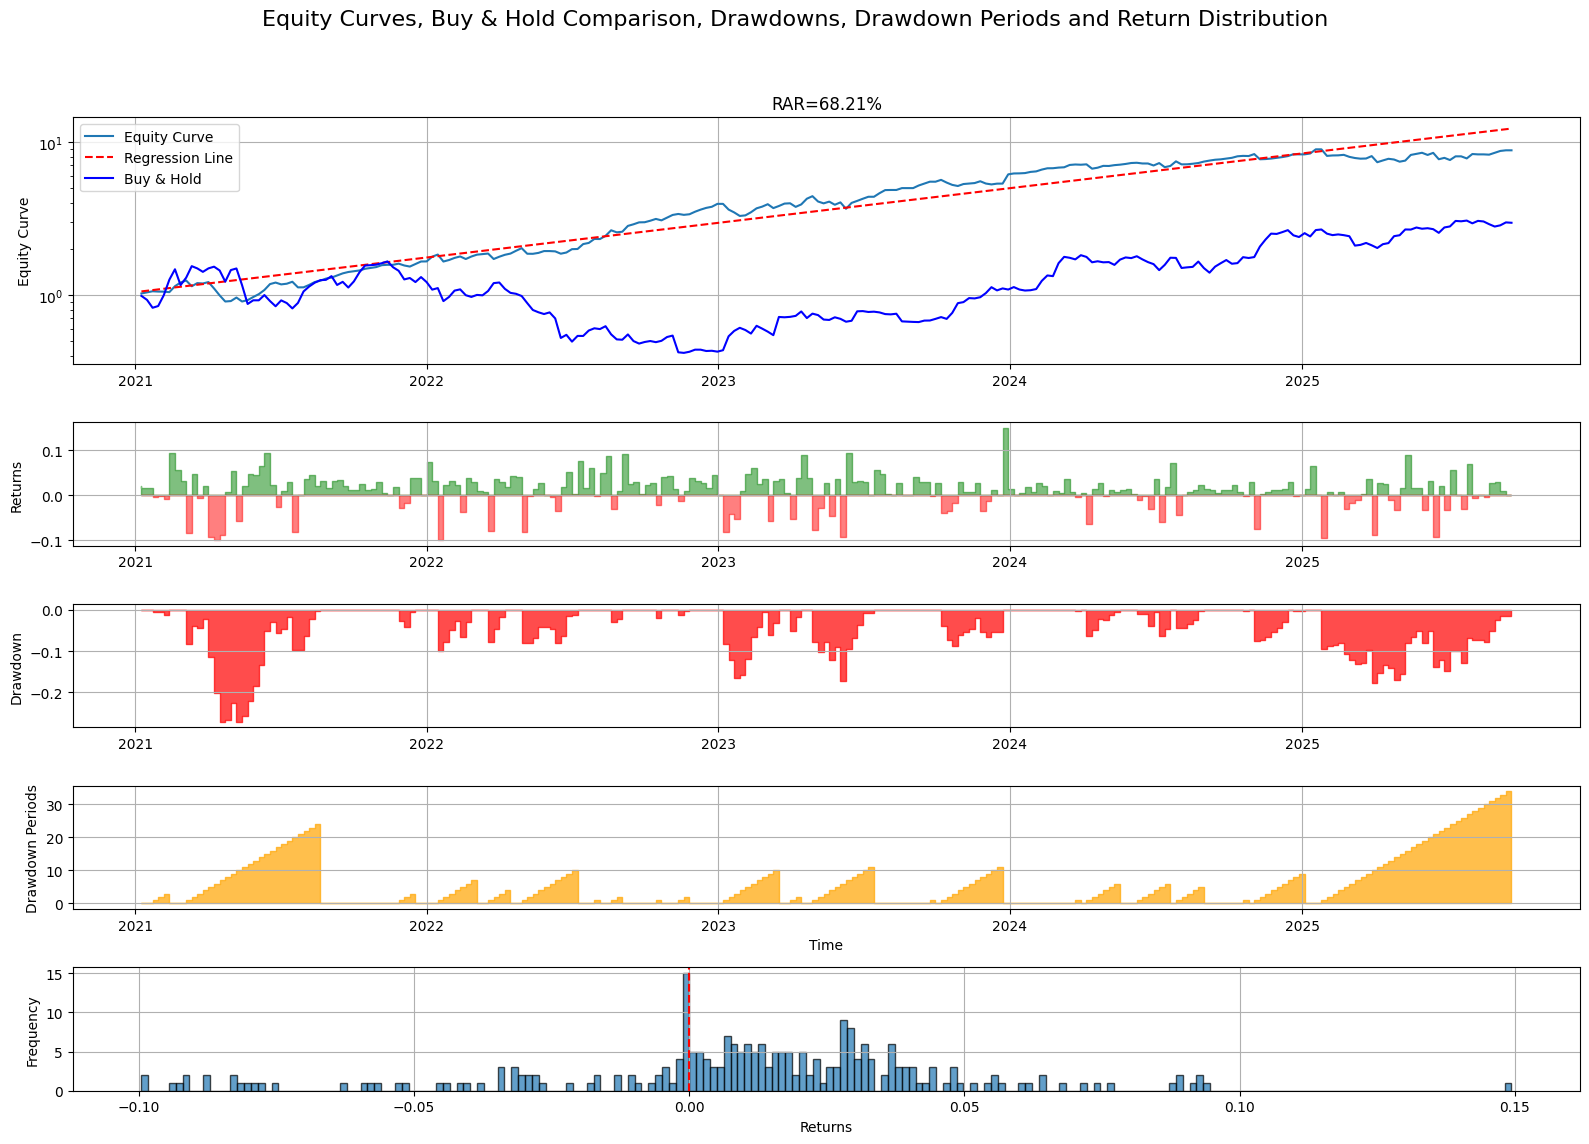

,Value
Metric,
Sharpe Ratio,1.81
R-Sharpe Ratio,1.90
Robust Risk-Reward Ratio,15.00
Sortino Ratio,2.98
Calmar Ratio,3.68
Maximum Drawdown,-27.10%
Longest Drawdown,34
Volatility,3.82%
Compounded Annual Growth Rate,58.32%


In [ ]:
results = wg1.rolling_optimize()
results

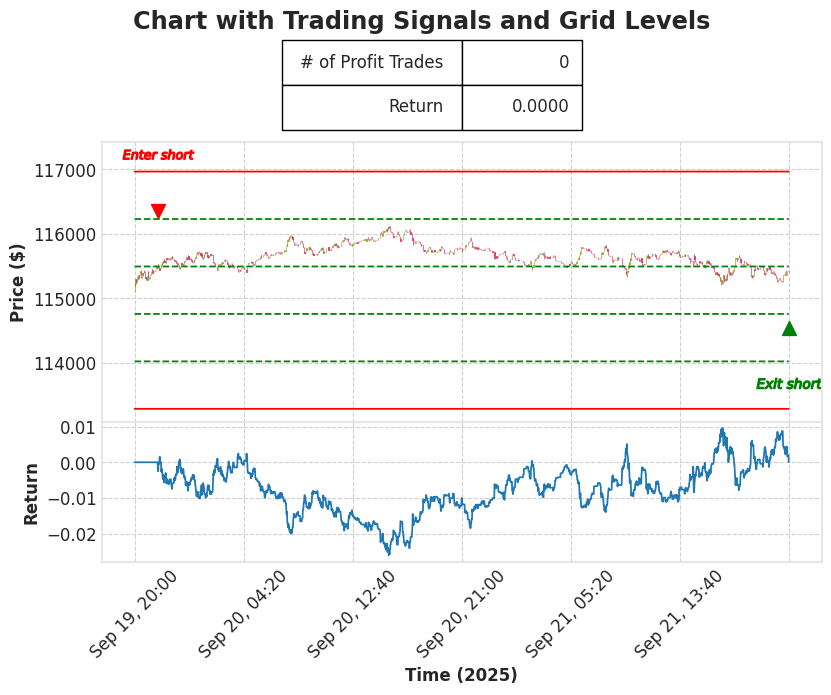

In [5]:
wg1.rolling_optimize(start='2025-09-14', signal_plot=True)

In [1]:
from helper import split_week, convert_interval
import pandas as pd

data = pd.read_csv('data/klines/BTCUSDT_1m.csv', parse_dates=['open_time'])
data = convert_interval(data, '1h')

In [2]:
weekdays, weekends = split_week(data)

In [4]:
weekends[-15]

,open_time,open,high,low,close,volume
0,2025-05-23 20:00:00,108714.01,108727.28,108186.55,108236.53,569.29475
1,2025-05-23 21:00:00,108236.53,108664.65,108055.00,108282.89,561.89055
2,2025-05-23 22:00:00,108282.89,108590.90,107638.96,107797.37,816.90940
3,2025-05-23 23:00:00,107797.37,107898.34,106800.00,107318.30,1387.09610
4,2025-05-24 00:00:00,107318.30,107680.83,106875.41,107366.68,926.99572
5,2025-05-24 01:00:00,107366.68,107875.66,107352.75,107479.24,437.55116
6,2025-05-24 02:00:00,107479.24,107900.11,107243.10,107803.84,383.40402
7,2025-05-24 03:00:00,107803.84,108367.54,107750.64,108366.30,573.36983
8,2025-05-24 04:00:00,108366.31,108582.33,108300.00,108485.07,403.76377
9,2025-05-24 05:00:00,108485.06,108530.73,108126.99,108235.68,437.82917


In [14]:
wg1.weekends[8]

,open_time,open,high,low,close,volume
0,2018-03-09 20:00:00,8770.01,8789.89,8770.01,8775.01,15.431710
1,2018-03-09 20:01:00,8786.25,8789.89,8770.64,8783.00,15.757853
2,2018-03-09 20:02:00,8786.00,8789.00,8770.69,8773.00,11.738387
3,2018-03-09 20:03:00,8773.00,8788.41,8763.01,8786.15,15.945219
4,2018-03-09 20:04:00,8788.65,8815.00,8780.00,8812.63,43.808812
...,...,...,...,...,...,...
3055,2018-03-11 22:55:00,9595.01,9641.90,9595.01,9620.30,27.587877
3056,2018-03-11 22:56:00,9620.32,9641.89,9600.97,9610.00,24.008055
3057,2018-03-11 22:57:00,9610.00,9615.00,9606.00,9614.80,12.548040
3058,2018-03-11 22:58:00,9614.00,9614.79,9550.00,9560.76,48.264921


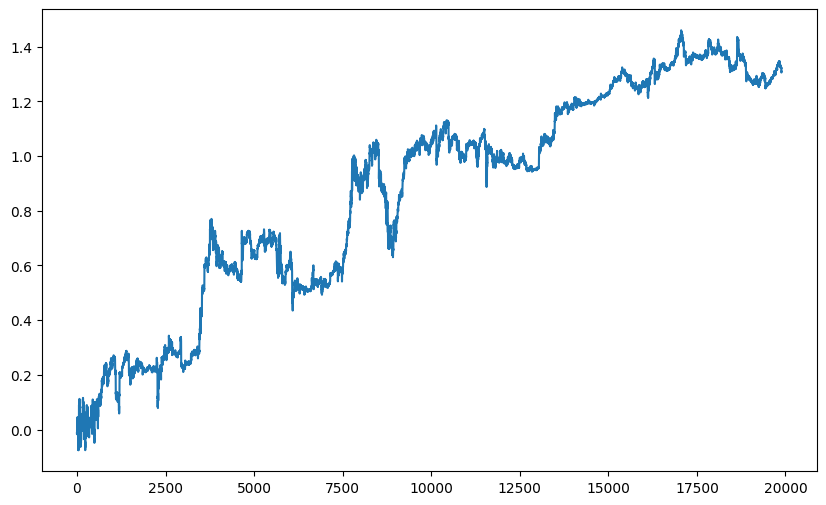

In [ ]:
import numpy as np
weekdays, weekends = split_week(data)
weekend_log_returns = []
for weekend in weekends:
    weekend_log_returns.append(np.diff(np.log(np.r_[weekend['open'].iloc[0], weekend['close']])))
        
log_returns = np.concatenate(weekend_log_returns)

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 6)
cum_returns = np.cumsum(log_returns)
plt.plot(cum_returns)
plt.show()


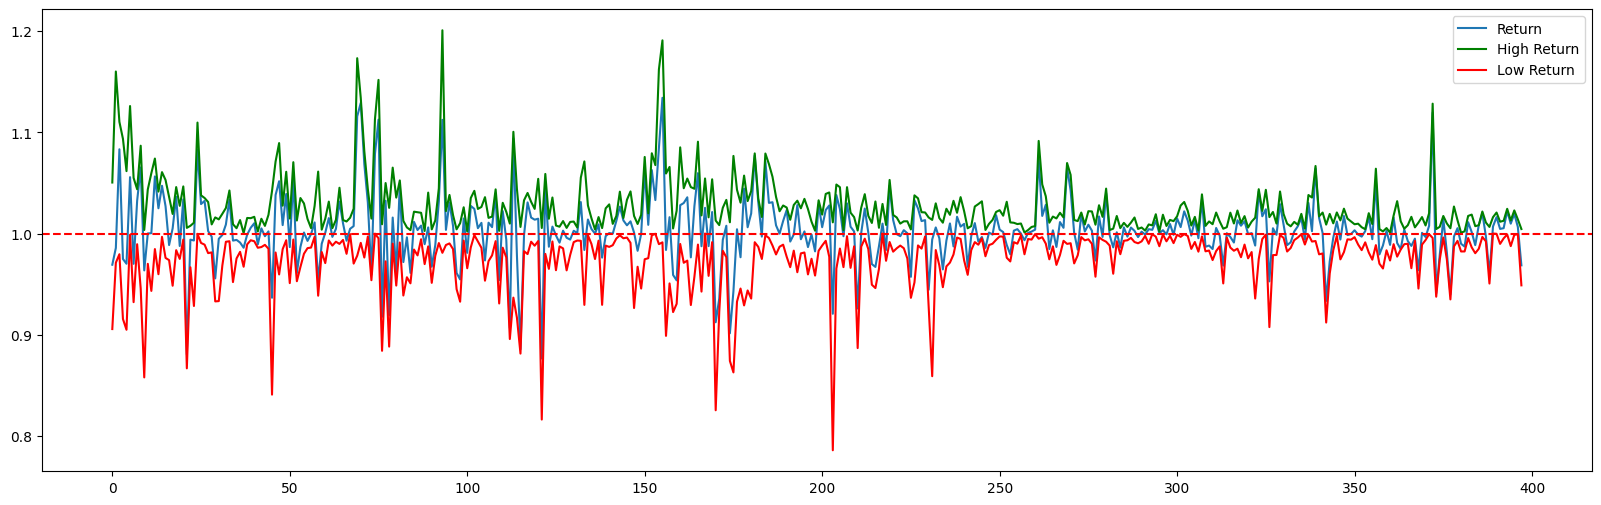

In [35]:
weekend_returns = np.array([sum(returns) for returns in weekend_log_returns])
h_returns = np.array([np.log(ohlc['high'].max()) - np.log(ohlc['open'].iloc[0]) for ohlc in weekends])
l_returns = np.array([np.log(ohlc['low'].min()) - np.log(ohlc['open'].iloc[0]) for ohlc in weekends])
plt.figure(figsize=(20, 6))
plt.plot(np.exp(weekend_returns), label='Return')
plt.plot(np.exp(h_returns), label='High Return', c='green')
plt.plot(np.exp(l_returns), label='Low Return', c='red')
plt.legend()
plt.axhline(1, color='red', linestyle='--')
plt.show()

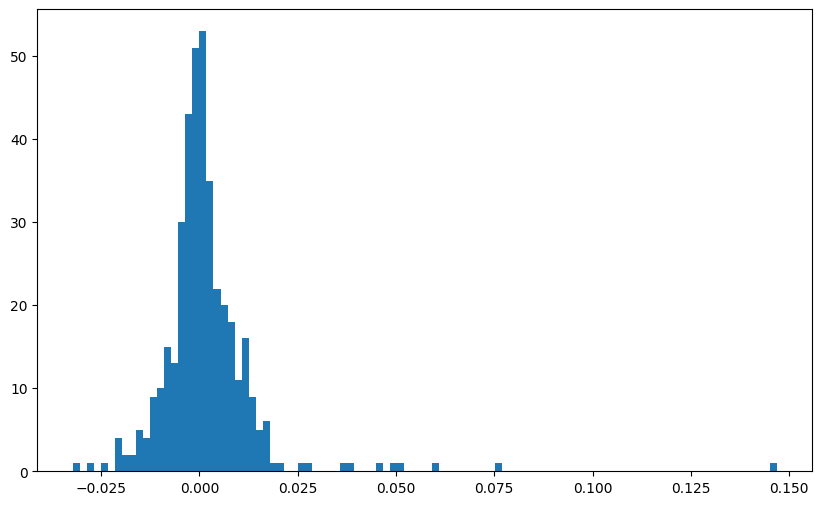

In [ ]:
plt.hist(weekend_returns, bins=100)
plt.show()

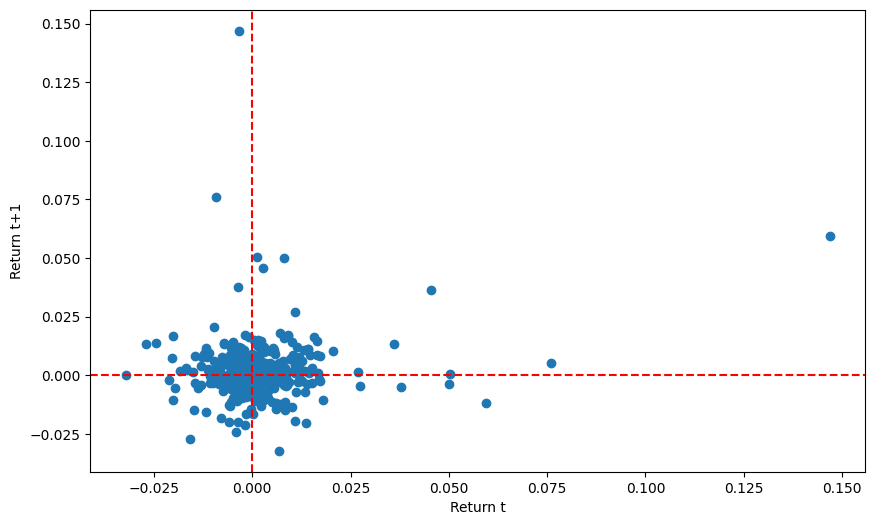

In [13]:
plt.scatter(weekend_returns[:-1], weekend_returns[1:])
plt.xlabel('Return t')
plt.ylabel('Return t+1')
plt.axhline(0, color='red', linestyle='--')
plt.axvline(0, color='red', linestyle='--')
plt.show()

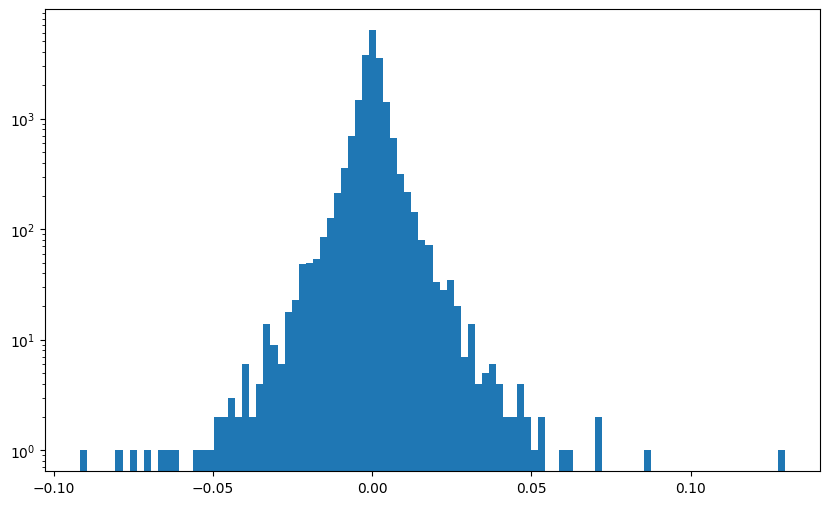

In [4]:
plt.hist(log_returns, bins=100)
plt.yscale('log')
plt.show()

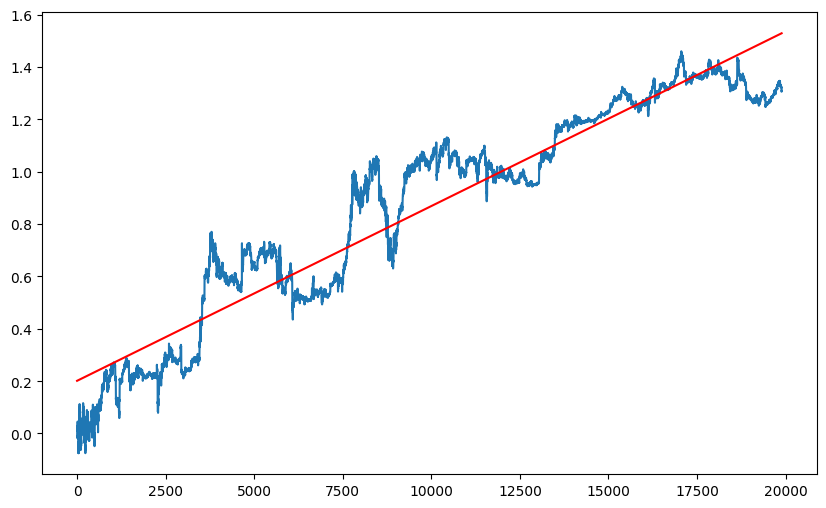

In [8]:
slope, intercept = np.polyfit(np.arange(len(cum_returns)), cum_returns, 1)
plt.plot(cum_returns)
reg_line = slope * np.arange(len(cum_returns)) + intercept
plt.plot(reg_line, c='red')
plt.show()

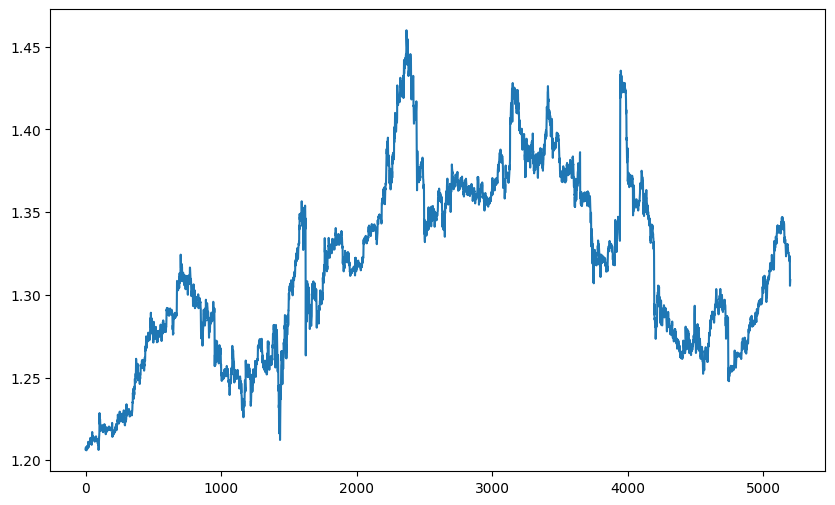

In [15]:
plt.plot(cum_returns[-50*52*2:])
plt.show()

```
open_time, O, H, L, C = data.iloc[i, :5]        0.09s
open_time, O, H, L, C = data.at[i, 'open_time'], data.at[i, 'open'], data.at[i, 'high'], data.at[i, 'low'], data.at[i, 'close']     0.02s
open_time = data['open_time'].iloc[i]
            O = data['open'].iloc[i]
            H = data['high'].iloc[i]
            L = data['low'].iloc[i]
            C = data['close'].iloc[i]       0.04s
open_time = data.at[i, 'open_time']
            O = data.at[i, 'open']
            H = data.at[i, 'high']
            L = data.at[i, 'low']
            C = data.at[i, 'close']         0.02s

```

### Kelly Formula
$Edge = (Win\ Probability \times Odds) - (1 - Win\ probability)$  
$Bet\ Size = Edge / Odds$

Sharpe:  > 1.25
Turnover: Average measure of daily trading activity, how often one trades, 1%-70%
Fitness = Sharpe * sprt(abs(Returns) / max(Turnover, 0.125)), > 1.0